# BirdCLEF+ 2026 Dataset EDA

This notebook checks only the dataset facts that are useful for the first implementation: label space, class imbalance, taxonomy groups, audio file availability, approximate audio durations, and submission format.

The intended modeling path is:

```text
audio -> Perch 2 backbone -> BirdCLEF+ classifier head -> class probabilities
```

In [16]:
from pathlib import Path
import ast
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Locate the downloaded competition data

In [5]:
DATA_ROOT = Path.home() / ".cache" / "kagglehub" / "competitions" / "birdclef-2026"


TRAIN_AUDIO_DIR = DATA_ROOT / "train_audio"
TEST_SOUND_DIR = DATA_ROOT / "test_soundscapes"

print(f"Data root:    {DATA_ROOT}")
print(f"Train audio:  {TRAIN_AUDIO_DIR.exists()} -> {TRAIN_AUDIO_DIR}")
print(f"Test audio:   {TEST_SOUND_DIR.exists()} -> {TEST_SOUND_DIR}")

Data root:    /d/hpc/home/ak1790/.cache/kagglehub/competitions/birdclef-2026
Train audio:  True -> /d/hpc/home/ak1790/.cache/kagglehub/competitions/birdclef-2026/train_audio
Test audio:   True -> /d/hpc/home/ak1790/.cache/kagglehub/competitions/birdclef-2026/test_soundscapes


## Load metadata tables

In [6]:
train = pd.read_csv(DATA_ROOT / "train.csv")
taxonomy = pd.read_csv(DATA_ROOT / "taxonomy.csv")
sample_submission = pd.read_csv(DATA_ROOT / "sample_submission.csv")

print("train:", train.shape)
print("taxonomy:", taxonomy.shape)
print("sample_submission:", sample_submission.shape)

display(train.head())
display(taxonomy.head())
display(sample_submission.iloc[:3, :8])

train: (35549, 15)
taxonomy: (234, 5)
sample_submission: (3, 235)


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197.mp3?1727581626,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648.mp3?1719714347,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.mp3?1694395513,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.mp3?1695610958,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.mp3?1667105088,1161364/iNat556514.ogg,iNat


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


## Label space used by the classifier

The classifier head should output one logit per submission class, in exactly this order.

In [7]:
target_labels = list(sample_submission.columns[1:])
train_labels = sorted(train["primary_label"].astype(str).unique())
taxonomy_labels = sorted(taxonomy["primary_label"].astype(str).unique())

print(f"Submission target classes: {len(target_labels)}")
print(f"Train primary labels:      {len(train_labels)}")
print(f"Taxonomy labels:           {len(taxonomy_labels)}")

missing_from_train = sorted(set(target_labels) - set(train_labels))
extra_train_labels = sorted(set(train_labels) - set(target_labels))

print(f"Targets missing from train primary labels: {len(missing_from_train)}")
print(f"Train labels not in submission targets:    {len(extra_train_labels)}")

print("First 10 target labels:", target_labels[:10])
print("Missing-from-train examples:", missing_from_train[:20])

Submission target classes: 234
Train primary labels:      206
Taxonomy labels:           234
Targets missing from train primary labels: 28
Train labels not in submission targets:    0
First 10 target labels: ['1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967']
Missing-from-train examples: ['1491113', '25073', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18']


## Class imbalance

This tells us whether weighted sampling or class-weighted loss will probably be useful.

,recordings_per_class
count,206.000000
mean,172.567961
std,155.371004
min,1.000000
25%,47.250000
50%,125.000000
75%,243.750000
max,499.000000


,count
primary_label,
rubthr1,499
banana,498
fepowl,497
soulap1,497
houspa,496
coffal1,495
osprey,495
socfly1,494
compau,493


,count
primary_label,
738183,5
23176,4
25214,3
476521,3
555123,3
64898,3
74580,3
sptnig1,3
209233,2


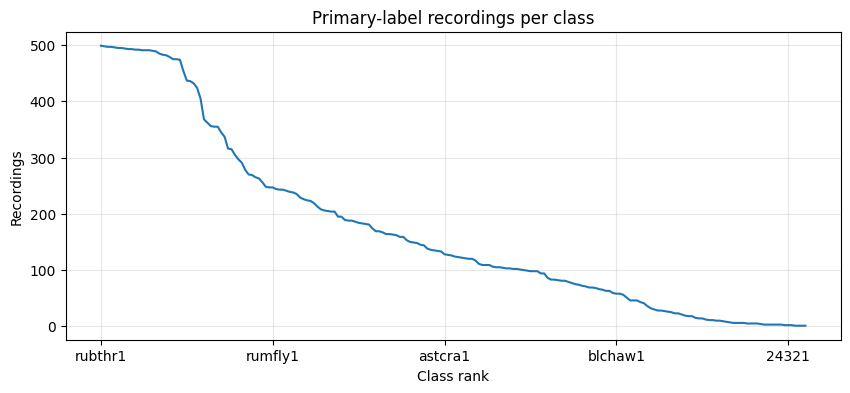

In [8]:
class_counts = train["primary_label"].astype(str).value_counts()

display(class_counts.describe().to_frame("recordings_per_class"))
display(class_counts.head(15).rename("count").to_frame())
display(class_counts.tail(15).rename("count").to_frame())

fig, ax = plt.subplots(figsize=(10, 4))
class_counts.sort_values(ascending=False).plot(ax=ax)
ax.set_title("Primary-label recordings per class")
ax.set_xlabel("Class rank")
ax.set_ylabel("Recordings")
ax.grid(alpha=0.3)
plt.show()

## Taxonomy groups

Useful later for checking whether Perch helps birds more than non-birds.

,num_classes
class_name,
Aves,162
Amphibia,35
Insecta,28
Mammalia,8
Reptilia,1


,num_recordings
class_name_taxonomy,
Aves,34799
Amphibia,451
Insecta,199
Mammalia,99
Reptilia,1


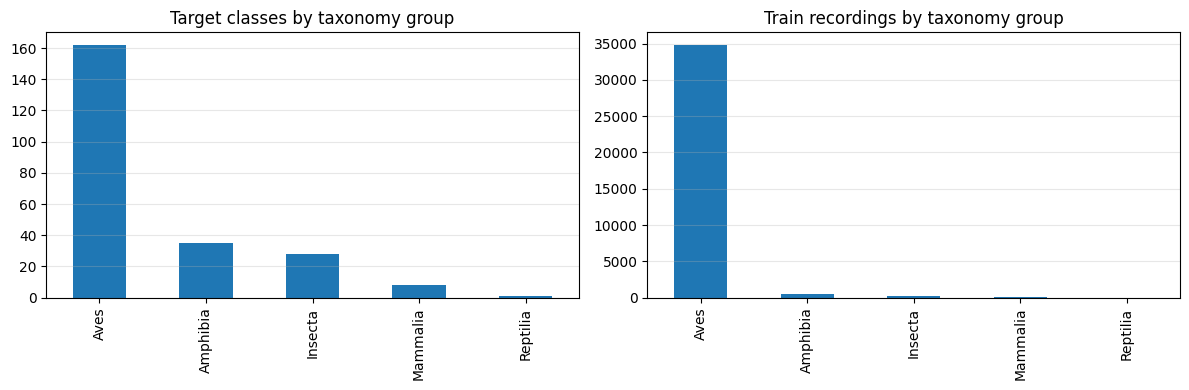

In [9]:
taxonomy_small = taxonomy[["primary_label", "common_name", "scientific_name", "class_name"]].copy()
taxonomy_small["primary_label"] = taxonomy_small["primary_label"].astype(str)

train_with_taxonomy = train.copy()
train_with_taxonomy["primary_label"] = train_with_taxonomy["primary_label"].astype(str)
train_with_taxonomy = train_with_taxonomy.merge(taxonomy_small, on="primary_label", how="left", suffixes=("", "_taxonomy"))

class_group_counts = taxonomy_small["class_name"].value_counts()
recording_group_counts = train_with_taxonomy["class_name_taxonomy"].fillna(train_with_taxonomy["class_name"]).value_counts()

display(class_group_counts.rename("num_classes").to_frame())
display(recording_group_counts.rename("num_recordings").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_group_counts.plot(kind="bar", ax=axes[0], title="Target classes by taxonomy group")
recording_group_counts.plot(kind="bar", ax=axes[1], title="Train recordings by taxonomy group")
for ax in axes:
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Secondary labels

Primary labels are the simplest starting point. This quick check tells us how often extra labels appear and whether they should be considered later for multi-label targets.

In [10]:
def parse_list_cell(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else []
    except (SyntaxError, ValueError):
        return []

secondary = train["secondary_labels"].apply(parse_list_cell)
num_secondary = secondary.apply(len)

print("Recordings with at least one secondary label:", int((num_secondary > 0).sum()))
print("Maximum secondary labels on one recording:", int(num_secondary.max()))
display(num_secondary.value_counts().sort_index().rename("num_recordings").to_frame())

Recordings with at least one secondary label: 4372
Maximum secondary labels on one recording: 15


,num_recordings
secondary_labels,
0,31177
1,2623
2,1049
3,379
4,169
5,87
6,35
7,11
8,12


## Audio file checks

Before writing loaders, check that filenames resolve and inspect a small duration sample.

In [12]:
train_paths = train["filename"].apply(lambda x: TRAIN_AUDIO_DIR / x)
exists_mask = train_paths.apply(lambda p: p.exists())

print(f"Existing train audio files: {exists_mask.sum()} / {len(exists_mask)}")
if not exists_mask.all():
    display(train.loc[~exists_mask, ["primary_label", "filename"]].head())

print("Example train path:", train_paths.iloc[0])

Existing train audio files: 35549 / 35549
Example train path: /d/hpc/home/ak1790/.cache/kagglehub/competitions/birdclef-2026/train_audio/1161364/iNat1216197.ogg


,primary_label,filename,collection,duration,samplerate,channels
19535,purjay1,purjay1/XC299441.ogg,XC,15.516000,32000,1
24086,saytan1,saytan1/iNat588079.ogg,iNat,8.661062,32000,1
30803,thlwre1,thlwre1/XC350961.ogg,XC,59.324094,32000,1
33271,whbwar2,whbwar2/XC835399.ogg,XC,15.125031,32000,1
33212,whbwar2,whbwar2/iNat502152.ogg,iNat,4.440000,32000,1


,duration,samplerate,channels
count,300.000000,300.0,300.0
mean,33.282555,32000.0,1.0
std,57.147967,0.0,0.0
min,0.104500,32000.0,1.0
25%,10.196953,32000.0,1.0
50%,20.352297,32000.0,1.0
75%,41.397555,32000.0,1.0
max,859.872000,32000.0,1.0


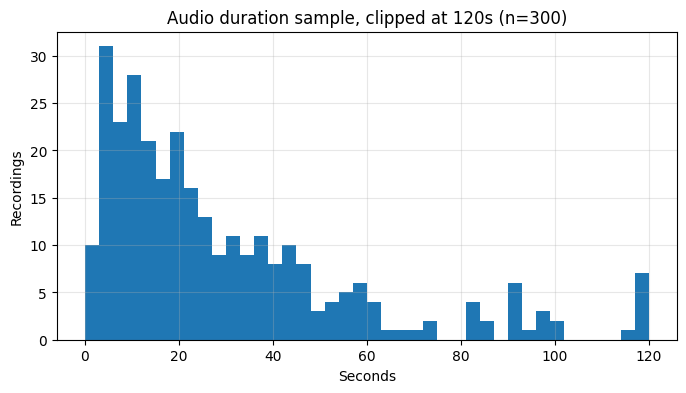

In [17]:
def get_audio_info(path):
    info = sf.info(path)
    return {"duration": info.duration, "samplerate": info.samplerate, "channels": info.channels}

sample_n = min(300, len(train_paths))
sample_paths = train_paths.sample(sample_n, random_state=SEED)
audio_info = pd.DataFrame([get_audio_info(p) for p in sample_paths], index=sample_paths.index)
audio_info = pd.concat([train.loc[sample_paths.index, ["primary_label", "filename", "collection"]], audio_info], axis=1)

display(audio_info.head())
display(audio_info[["duration", "samplerate", "channels"]].describe())

fig, ax = plt.subplots(figsize=(8, 4))
audio_info["duration"].dropna().clip(upper=120).hist(bins=40, ax=ax)
ax.set_title(f"Audio duration sample, clipped at 120s (n={sample_n})")
ax.set_xlabel("Seconds")
ax.set_ylabel("Recordings")
ax.grid(alpha=0.3)
plt.show()

## Submission format

These columns define the classifier output order. Each row corresponds to a 5-second test window.

In [19]:
print("Rows in sample submission:", len(sample_submission))
print("Target columns:", len(sample_submission.columns) - 1)
print("First row_id examples:")
display(sample_submission[["row_id"]].head(10))

Rows in sample submission: 3
Target columns: 234
First row_id examples:


,row_id
0,BC2026_Test_0001_S05_20250227_010002_5
1,BC2026_Test_0001_S05_20250227_010002_10
2,BC2026_Test_0001_S05_20250227_010002_15


## Practical takeaways for the implementation

- Use `sample_submission.columns[1:]` as the canonical class order for the classifier head.
- Save the train/validation split once; all experiments should reuse it.
- Start with primary labels only, then consider secondary labels later.
- Expect class imbalance; keep class weighting or weighted sampling as an early experiment.
- Use taxonomy groups later to compare bird vs non-bird validation performance.
- Training/inference audio windowing must match the 5-second submission windows.